# Network summary table — the three datasets

Thesis-ready summary table with the structural characteristics of each dataset
(nodes, edges, density, clustering coefficient, average path length, …),
accompanied by a figure with the three graphs side by side.

Inputs are produced by `dataset_{1,2,3}/network_summary.ipynb`
(run those first — they save the metric CSVs and the layout coordinates).

Outputs (`src/data/network_summary/`): `network_summary_table.csv`,
`network_summary_table.tex`, and `network_graphs_three_datasets.png` (saved here in `00_notes/`).

In [1]:
import sys
from pathlib import Path

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path

OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'network_summary'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB_DIR = PROJECT_ROOT / 'src' / 'notebooks' / '00_notes'


## Summary table

In [2]:
LABELS = {
    'n_nodes': 'Number of nodes',
    'n_edges': 'Number of edges (directed)',
    'density': 'Density',
    'avg_degree': 'Average degree (in + out)',
    'max_degree': 'Max degree',
    'reciprocity': 'Reciprocity',
    'avg_clustering': 'Average clustering coefficient',
    'degree_assortativity': 'Degree assortativity',
    'n_components': 'Connected components',
    'lcc_size': 'Largest component size',
    'lcc_share': 'Largest component share',
    'avg_path_length': 'Average path length (LCC)',
    'diameter': 'Diameter (LCC)',
}
COUNTS = {'n_nodes', 'n_edges', 'max_degree', 'n_components', 'lcc_size', 'diameter'}

cols = {
    'Dataset 1 (mean, 32 quarters)': pd.read_csv(OUT_DIR / 'dataset_1_summary.csv', index_col='metric')['value'],
    'Dataset 2': pd.read_csv(OUT_DIR / 'dataset_2_summary.csv', index_col='metric')['value'],
    'Dataset 3': pd.read_csv(OUT_DIR / 'dataset_3_summary.csv', index_col='metric')['value'],
}
table_raw = pd.DataFrame(cols).loc[list(LABELS)]

def fmt(metric, v):
    if pd.isna(v):
        return '—'
    if metric in COUNTS:
        return f'{v:,.0f}'
    if metric == 'lcc_share':
        return f'{v:.1%}'
    if metric == 'density':
        return f'{v:.2e}'
    return f'{v:.3f}'

table = table_raw.copy()
for c in table.columns:
    table[c] = [fmt(m, v) for m, v in table_raw[c].items()]
table.index = [LABELS[m] for m in table.index]
table.index.name = None

table.to_csv(OUT_DIR / 'network_summary_table.csv')
table.to_latex(OUT_DIR / 'network_summary_table.tex', column_format='lrrr')
table

,"Dataset 1 (mean, 32 quarters)",Dataset 2,Dataset 3
Number of nodes,"4,548","1,444","10,000"
Number of edges (directed),"12,300","2,893","9,056"
Density,5.95e-04,1.39e-03,9.06e-05
Average degree (in + out),5.409,4.007,1.811
Max degree,"1,101",228,9
Reciprocity,0.028,0.018,0.000
Average clustering coefficient,0.121,0.086,0.000
Degree assortativity,-0.417,-0.279,-0.014
Connected components,177,1,"1,958"
Largest component size,"4,372","1,444","7,403"


## Figure — the three graphs

Largest connected component of each network, using the layouts saved by the
per-dataset notebooks (Dataset 1: representative quarter 2023 Q4).

In [3]:
from src.data import load_data

def lcc_graph(edges_df, src, dst):
    G = nx.Graph()
    G.add_edges_from(edges_df[[src, dst]].itertuples(index=False, name=None))
    return G.subgraph(max(nx.connected_components(G), key=len))

# Dataset 1 — representative quarter
edges1, _ = load_data(2023, 4)
U1 = lcc_graph(edges1, 'Sourceid', 'Targetid')

# Dataset 2 — adjacency matrix
matrix = pd.read_excel(PROJECT_ROOT / 'src' / 'datasets' / 'dataset_2' / 'network.xlsx', index_col=0)
edges2 = matrix.stack().reset_index()
edges2.columns = ['source_bank', 'target_bank', 'weight']
edges2 = edges2[edges2['weight'] != 0]
U2 = lcc_graph(edges2, 'source_bank', 'target_bank')

# Dataset 3 — ER edge list
edges3 = pd.read_csv(PROJECT_ROOT / 'src' / 'datasets' / 'dataset_3' / 'edges.csv')
U3 = lcc_graph(edges3, 'from', 'to')

def load_layout(name):
    df = pd.read_csv(OUT_DIR / f'{name}_layout.csv')
    return {n: (x, y) for n, x, y in df.itertuples(index=False, name=None)}

pos1, pos2, pos3 = load_layout('dataset_1'), load_layout('dataset_2'), load_layout('dataset_3')
print(len(U1), len(U2), len(U3))

Loaded 2023 Q4: 4548 banks, 12465 edges


4414 1444 7403


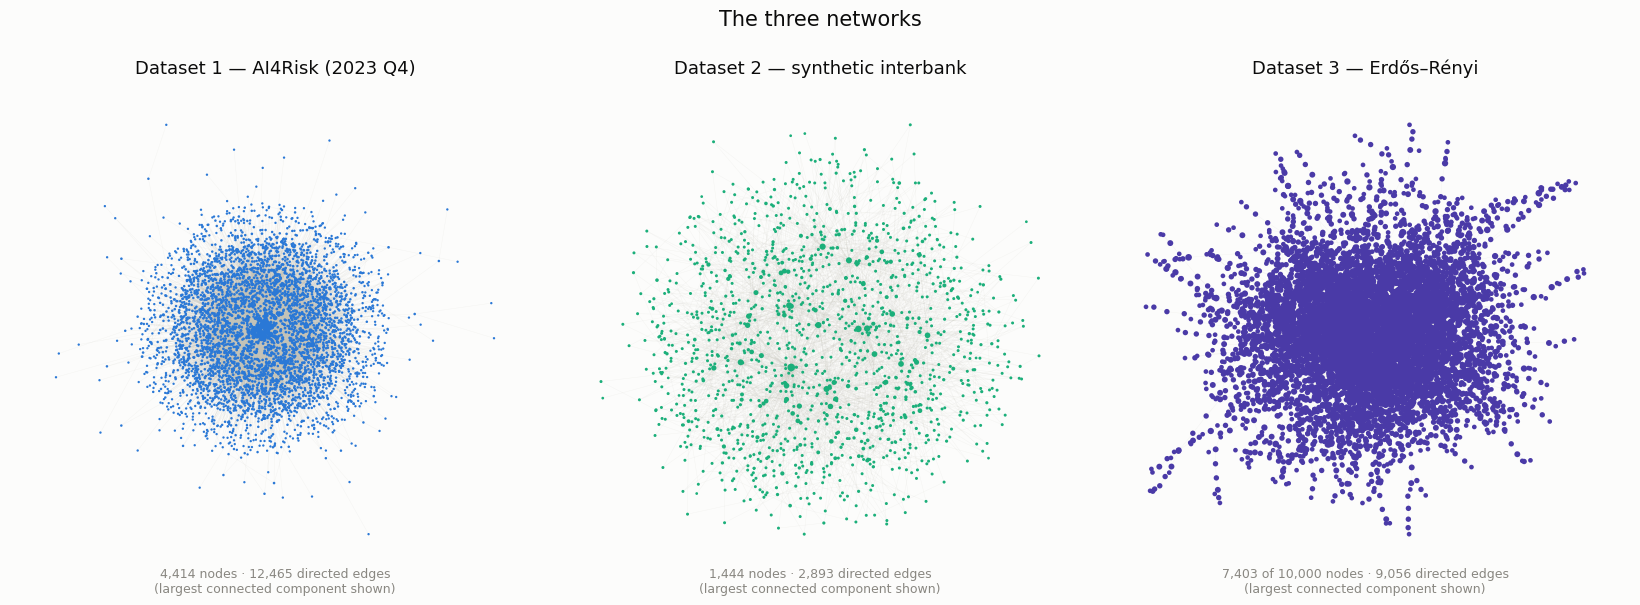

In [4]:
# Figure style (thesis palette)
SURFACE, INK, MUTED, EDGE_COLOR = '#fcfcfb', '#0b0b0b', '#898781', '#c3c2b7'

def draw_network(U_lcc, pos, color, title, subtitle, out_path, ax=None):
    deg = dict(U_lcc.degree())
    s = np.array([deg[n] for n in U_lcc.nodes()], dtype=float)
    sizes = 2 + 28 * np.sqrt(s / s.max())

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    nx.draw_networkx_edges(U_lcc, pos, ax=ax, edge_color=EDGE_COLOR, alpha=0.15, width=0.3)
    nx.draw_networkx_nodes(U_lcc, pos, ax=ax, node_color=color, node_size=sizes, linewidths=0)
    ax.set_title(title, color=INK, fontsize=13)
    ax.text(0.5, -0.03, subtitle, transform=ax.transAxes, ha='center', color=MUTED, fontsize=9)
    ax.set_axis_off()
    if own_fig:
        fig.savefig(out_path, dpi=200, facecolor=SURFACE, bbox_inches='tight')
        plt.show()

panels = [
    (U1, pos1, '#2a78d6', 'Dataset 1 — AI4Risk (2023 Q4)', f'{U1.number_of_nodes():,} nodes · {len(edges1):,} directed edges'),
    (U2, pos2, '#1baf7a', 'Dataset 2 — synthetic interbank', f'{U2.number_of_nodes():,} nodes · {len(edges2):,} directed edges'),
    (U3, pos3, '#4a3aa7', 'Dataset 3 — Erdős–Rényi', f'{U3.number_of_nodes():,} of 10,000 nodes · {len(edges3):,} directed edges'),
]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 6), facecolor=SURFACE)
for ax, (U, pos, color, title, subtitle) in zip(axes, panels):
    draw_network(U, pos, color, title, subtitle + '\n(largest connected component shown)', None, ax=ax)

fig.suptitle('The three networks', color=INK, fontsize=15, y=1.0)
fig.tight_layout()
fig.savefig(NB_DIR / 'network_graphs_three_datasets.png', dpi=200, facecolor=SURFACE, bbox_inches='tight')
plt.show()